In [1]:
import numpy as np
import pandas as pd
import glob
from numba import guvectorize
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
from datetime import datetime, timezone
import re
import json
import awkward as ak
import pygama 


from dbetto import Props
from legendmeta import LegendMetadata
from lgdo import lh5
import lgdo
from dspeed.vis.waveform_browser import WaveformBrowser
from pygama.pargen.dsp_optimize import run_one_dsp
import lgdo.types as lgdo_types
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.patches as mpatches
from collections import defaultdict
from pathlib import Path

import itertools
from tqdm import tqdm
import time


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.12/site-packages/tornado

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



# Path to data

In [2]:
data_path = "/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest"
config = Props.read_from(os.path.join(data_path, "config.json"), subst_pathvar=True)["setups"]["l200"]["paths"]


In [3]:
lmeta  = LegendMetadata(config["metadata"])
chmap = ak.Array(lmeta.channelmap(lmeta.dataprod.runinfo.p08.r004.phy.start_key).group("system").geds.values())

In [4]:
det = chmap[0]

det.analysis.fields


['processable', 'is_blinded', 'usability', 'reason', 'psd']

# Masck for detector type

In [5]:
names = chmap["name"]
mask_icpc = (names[:, 0] == "V")
mask_bege = (names[:, 0] == "B")
mask_coax = (names[:, 0] == "C")
mask_ppc  = (names[:, 0] == "P")

In [6]:
mask_ppc

False

# Functions

In [17]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) 

In [18]:
def fit_baseline(waves, calcs, i_start=0, i_end=1024, order=1):
    """ Polynomial fit [order], vectorized version of baseline calcsulator
    TODO: arbitrary orders?
    """
    wf_block = waves["waveform"]

    # run polyfit
    x = np.arange(i_start, i_end)
    wfs = wf_block[:, i_start:i_end].T
    pol = np.polynomial.polynomial.polyfit(x, wfs, order).T

    # add the result as new columns
    calcs["bl_int"] = pol[:,0]
    calcs["bl_slope"] = pol[:,1]
    return calcs


In [19]:
def fit_baseline_per_event(values, i_start=0, i_end=1024, order=1):

    
    x = np.arange(i_start, i_end)
    y = values[:, i_start:i_end]

    coeffs = np.array([
        np.polynomial.polynomial.polyfit(x, y[i], order).T
        for i in range(y.shape[0])
    ])

    return ak.Array([
        {
            "event": i,
            "bl_int": coeffs[i, 0],
            "bl_slope": coeffs[i, 1] if order > 0 else 0.0
        }
        for i in range(len(coeffs))
    ])

In [20]:
def load_waveforms(mask, chmap, fft_files):
    icpc_chmap = chmap[mask]
    all_events = []

    for chn in tqdm(ak.to_numpy(icpc_chmap.daq.rawid)):
        data = lh5.read_as(
            f"/ch{int(chn)}/raw",
            fft_files,
            field_mask=["waveform_presummed"],
            library="ak"
        )

        ch_array = ak.with_field(data, int(chn), "rawid")
        all_events.append(ch_array)

    return ak.concatenate(all_events)

In [21]:
def compute_baseline_all(wf, i_start=0, i_end=1024, order=1):

    x = np.arange(i_start, i_end)

    bl_int = np.empty(len(wf))
    bl_slope = np.empty(len(wf))

    for i in tqdm(range(len(wf)), desc="Baseline fit"):
        y = wf[i, i_start:i_end]

        coeff = np.polynomial.polynomial.polyfit(x, y, order)

        bl_int[i] = coeff[0]
        bl_slope[i] = coeff[1] if order > 0 else 0

      

    return bl_int, bl_slope

# Take data

For the baseline slope cuts you need:
- presummed waveforms
- fft data OR (in oldest periods) FT in phy data

In [22]:
detector = "P00698B"
chn = chmap.daq.rawid[chmap.name == detector][0]

In [46]:
config['tier_raw']

'/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest/../v0.1.0/generated/tier/raw'

In [49]:
config['tier_raw']
fft_files = sorted(glob.glob(f"{config['tier_raw']}/fft/p08/r004/l200-p08-r004-fft-20231030T184107Z-tier_raw.lh5"))


In [53]:
lh5.show(fft_files[0]);

/
├── FCConfig · table{packet_id,packet_len,readout_id,fcid,telid,nadcs,ntriggers,nsamples,adcbits,sumlength,blprecision,mastercards,triggercards,adccards,gps,ch_board_id,ch_inputnum,board_rev,board_uid} 
│   ├── adcbits · array<1>{real} 
│   ├── adccards · array<1>{real} 
│   ├── blprecision · array<1>{real} 
│   ├── board_rev · array<1>{array<1>{real}} 
│   │   ├── cumulative_length · array<1>{real} 
│   │   └── flattened_data · array<1>{real} 
│   ├── board_uid · array<1>{array<1>{real}} 
│   │   ├── cumulative_length · array<1>{real} 
│   │   └── flattened_data · array<1>{real} 
│   ├── ch_board_id · array<1>{array<1>{real}} 
│   │   ├── cumulative_length · array<1>{real} 
│   │   └── flattened_data · array<1>{real} 
│   ├── ch_inputnum · array<1>{array<1>{real}} 
│   │   ├── cumulative_length · array<1>{real} 
│   │   └── flattened_data · array<1>{real} 
│   ├── fcid · array<1>{real} 
│   ├── gps · array<1>{real} 
│   ├── mastercards · array<1>{real} 
│   ├── nadcs · array<1>{real

In [55]:
start = time.time()
data_init = lh5.read_as(f"/ch{int(chn)}/raw", fft_files, field_mask = ["waveform_presummed", "daqenergy "], library="ak")
print("Took", time.time() - start, "s to read")

Took 1.0666162967681885 s to read


In [56]:
lmeta

LegendMetadata('/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/v2.1.5/inputs')

In [26]:
data_init

<Array [{waveform_presummed: {...}}, ...] type='6565 * {waveform_presummed:...'>

In [27]:
wfs = data_init["waveform_presummed"]
wfs_ADC = ak.to_numpy(wfs["values"])

In [28]:
calcs = fit_baseline_per_event(wfs_ADC)

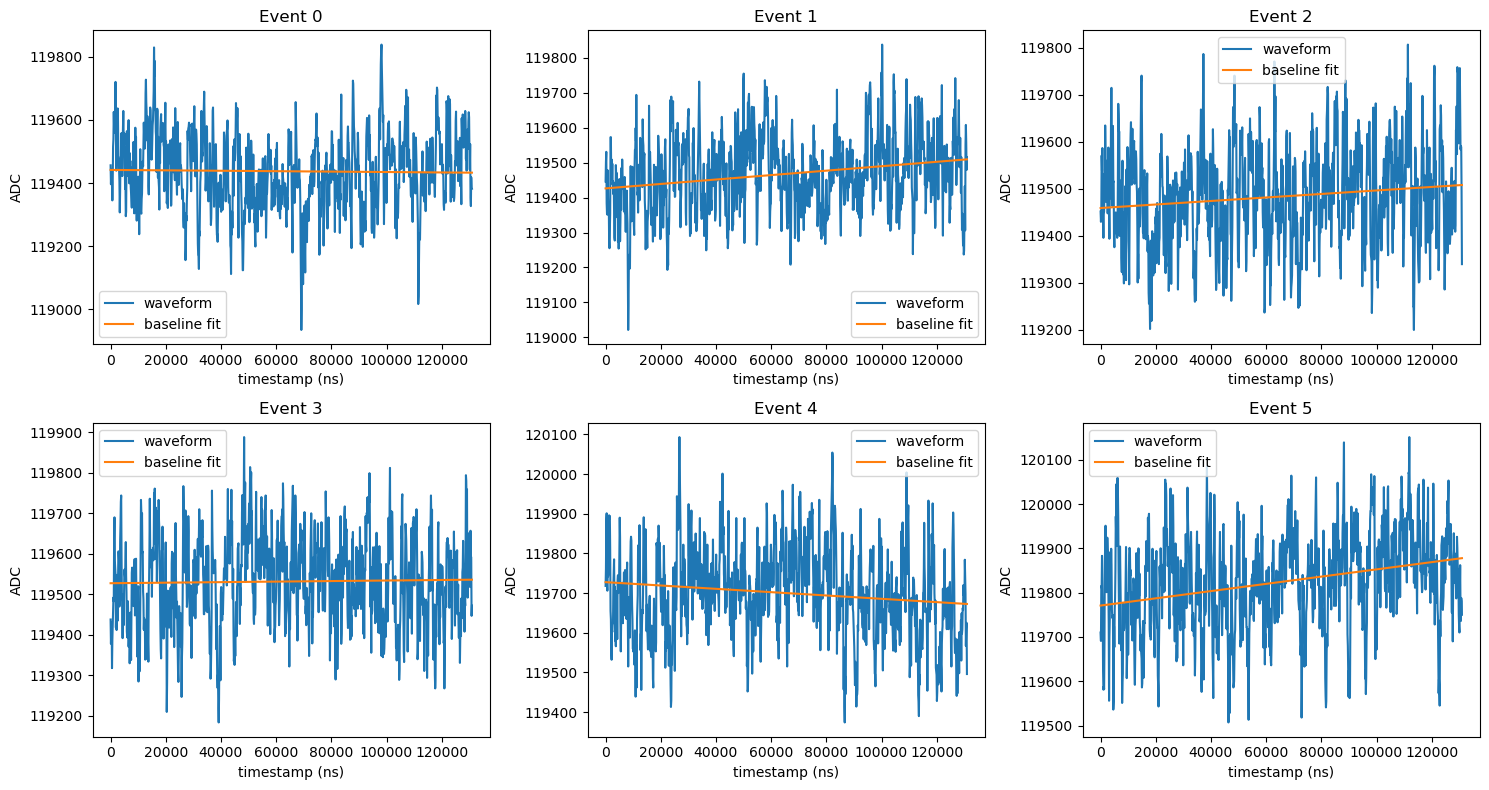

In [29]:
n_events = 6

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i in range(n_events):

    wf = wfs_ADC[i]
    t0 = data_init["waveform_presummed"][i]["t0"]
    dt = data_init["waveform_presummed"][i]["dt"]

    # asse tempo (o samples se preferisci)
    timestamp = t0 + np.arange(len(wf)) * dt

    # baseline fit
    x_fit = np.arange(len(wf))
    baseline = calcs["bl_int"][i] + calcs["bl_slope"][i] * x_fit

    ax = axes[i]
    ax.plot(timestamp, wf, label="waveform")
    ax.plot(timestamp, baseline, label="baseline fit")

    ax.set_title(f"Event {i}")
    ax.set_xlabel("timestamp (ns)")
    ax.set_ylabel("ADC")
    ax.legend()

plt.tight_layout()
plt.show()

[ 1.32967369e+02 -1.72452447e-03  6.53219411e-02]
[1.50563815e+00 8.54089339e-04 8.54103317e-04]


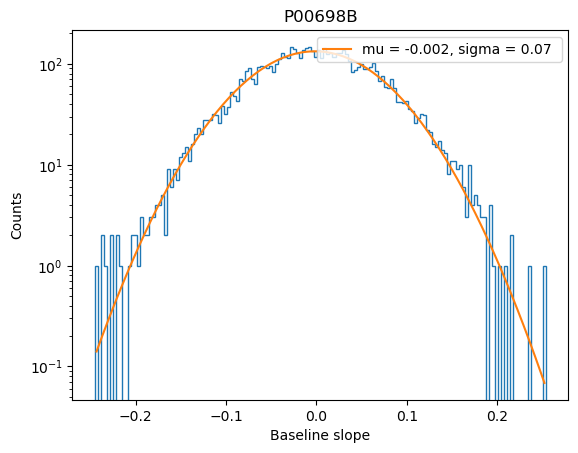

In [31]:
# Distirbution of the bl_sòlope parmaeter
# Here i'lll collect the mean and the  sigma in order to build the classifier
from scipy.optimize import curve_fit

counts, bc, _ = plt.hist(calcs["bl_slope"], bins = 150, histtype = 'step')
be = (bc[1:] + bc[:-1])/2

p0 = [max(counts), 0.1, 0.1]
popt, pcov = curve_fit(
        gaussian,
        be,
        counts,
        p0=p0,
        maxfev=5000
    )
mu = popt[1]
sigma = popt[2]

print(popt)
print(np.sqrt(np.diag(pcov)))

plt.plot(be, gaussian(be, *popt), label = f"mu = {popt[1]:.3f}, sigma = {popt[2]:.2f} ")

plt.legend(loc = "upper right")
plt.ylabel(f"Counts")
plt.xlabel("Baseline slope")
plt.title(f"{detector}")
plt.yscale('log')

[1.32967096e+02 2.44907773e-06 1.00000408e+00]
[1.50563648 0.01308094 0.01307533]


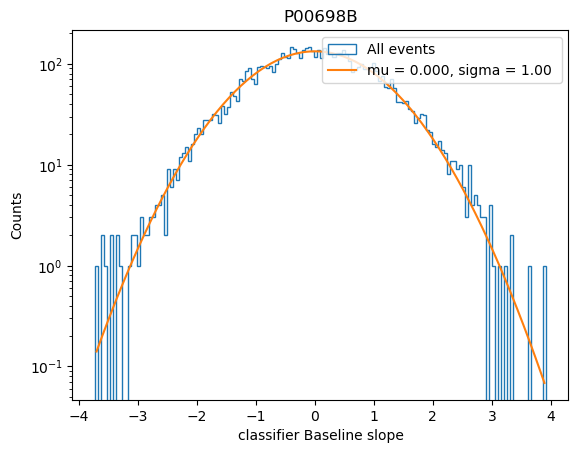

In [33]:
classifier_bl_slope = (calcs["bl_slope"] - mu) / sigma

counts, bc, _ = plt.hist(classifier_bl_slope, bins = 150, histtype = 'step', label=  "All events")


be = (bc[1:] + bc[:-1])/2
p0 = [max(counts), 0.1, 0.1]
popt, pcov = curve_fit(
        gaussian,
        be,
        counts,
        p0=p0,
        maxfev=5000
    )
mu = popt[1]
sigma = popt[2]

print(popt)
print(np.sqrt(np.diag(pcov)))
plt.plot(be, gaussian(be, *popt), label = f"mu = {popt[1]:.3f}, sigma = {popt[2]:.2f} ")

plt.legend(loc = "upper right")
plt.ylabel(f"Counts")
plt.xlabel("classifier Baseline slope")
plt.title(f"{detector}")
plt.yscale('log')

# ALL the ICPC

In [34]:
config['tier_raw']
fft_files = sorted(glob.glob(f"{config['tier_raw']}/fft/p08/r004/l200-p08-r004-fft-20231030T184107Z-tier_raw.lh5"))


In [35]:
names = ak.to_numpy(chmap["name"]).astype(str)

masks = {
    "ICPC": np.char.startswith(names, "V"),
    "BEGe": np.char.startswith(names, "B"),
    "Coax": np.char.startswith(names, "C"),
    "PPC":  np.char.startswith(names, "P"),
}

In [39]:
icpc_chmap = chmap[masks['ICPC']]

In [40]:
chn_icpc = icpc_chmap.daq.rawid


In [41]:
icpc_chmap['name'][10:20]

<Array ['V04549A', 'V07298B', ..., 'V08682A', 'V09372A'] type='10 * string'>

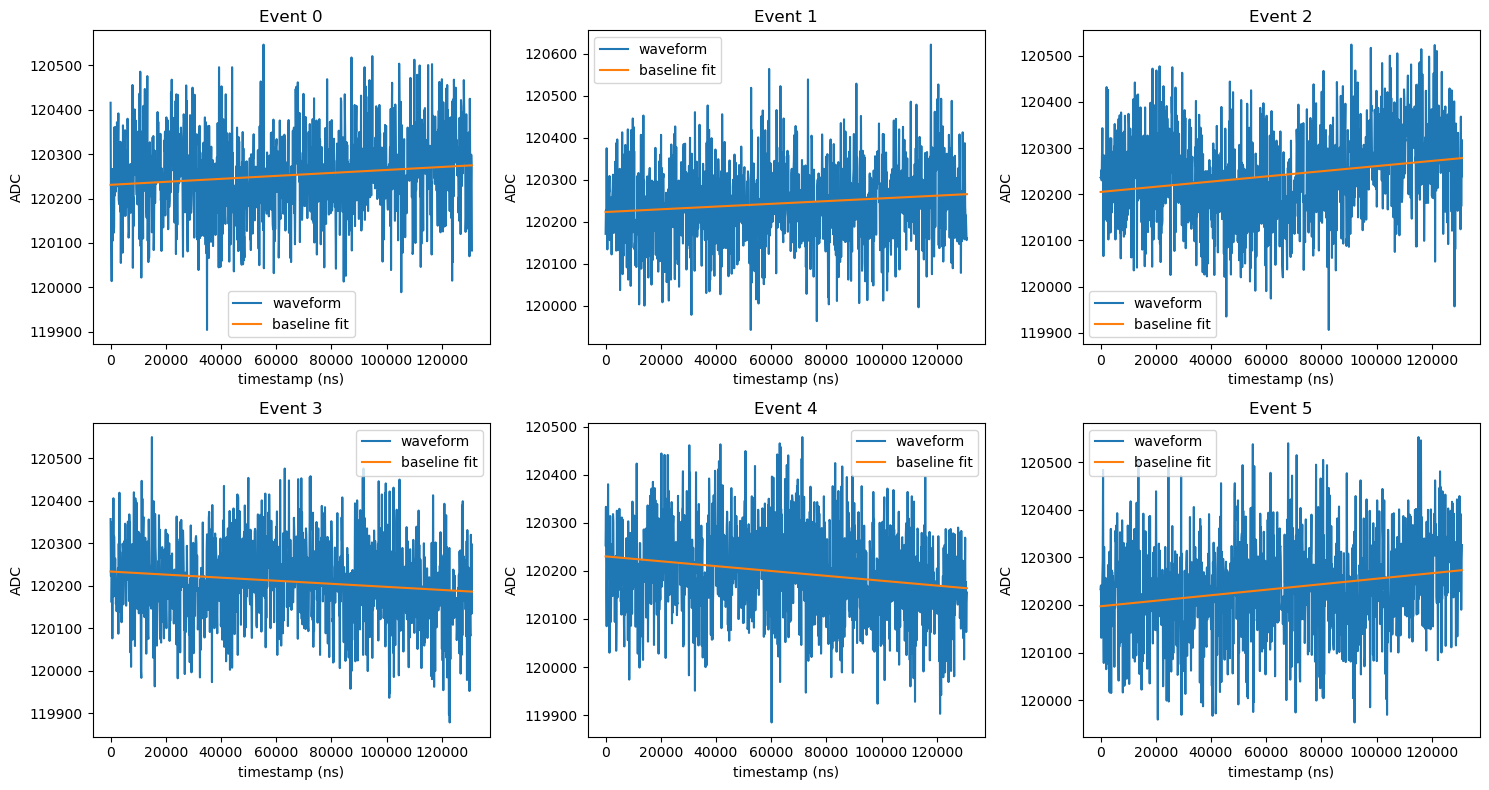

[ 2.27397534e+02 -8.83678066e-07  1.00000445e+00]
[1.89727476 0.00958159 0.00963445]


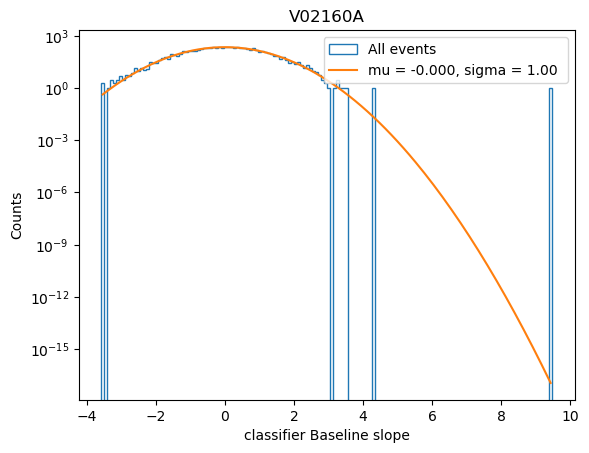

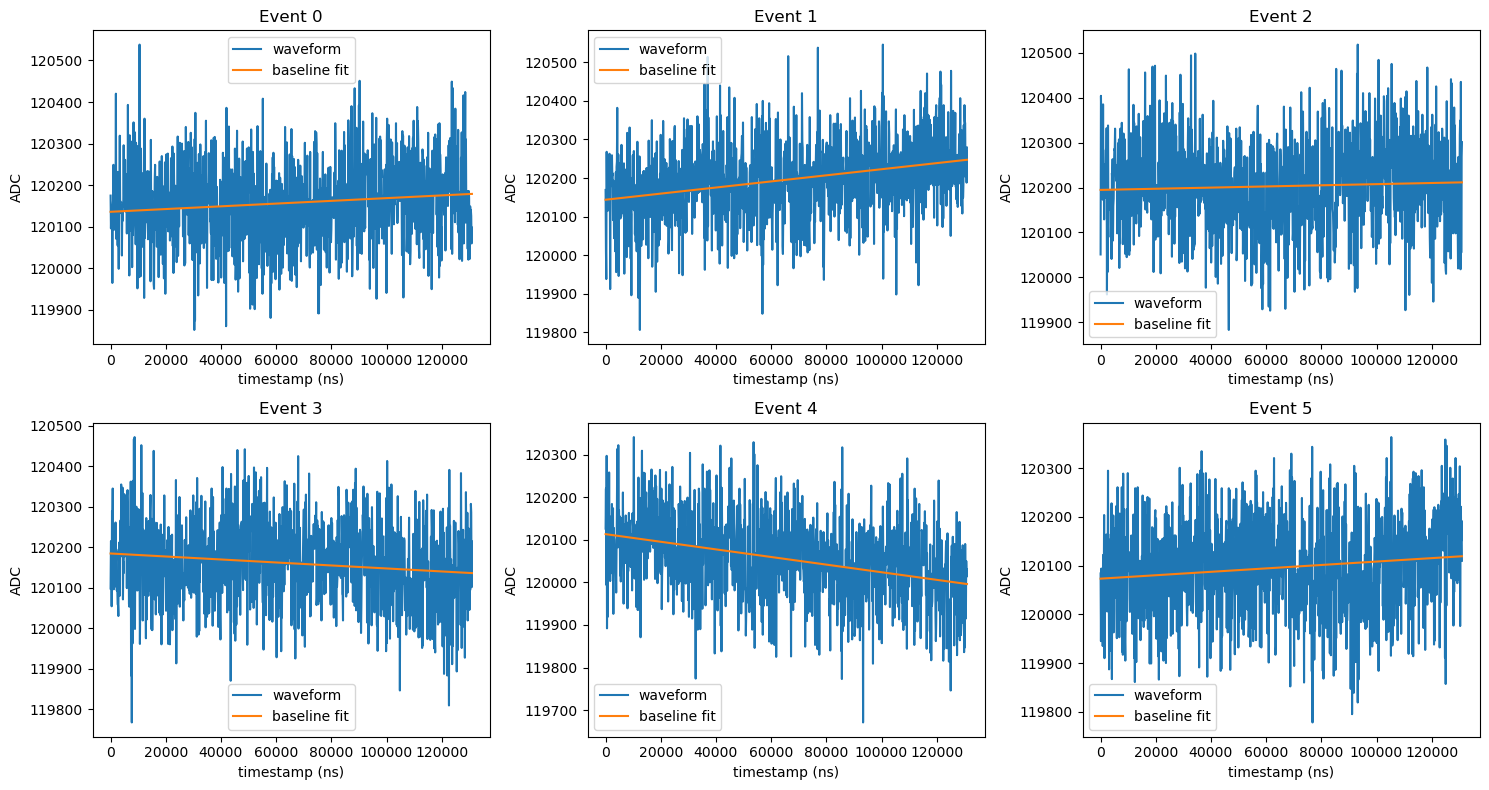

[1.38588890e+02 4.99509546e-06 1.00000005e+00]
[1.34206271 0.01117566 0.01118208]


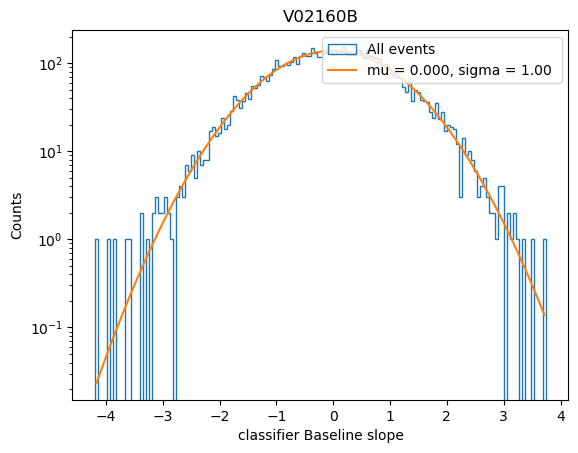

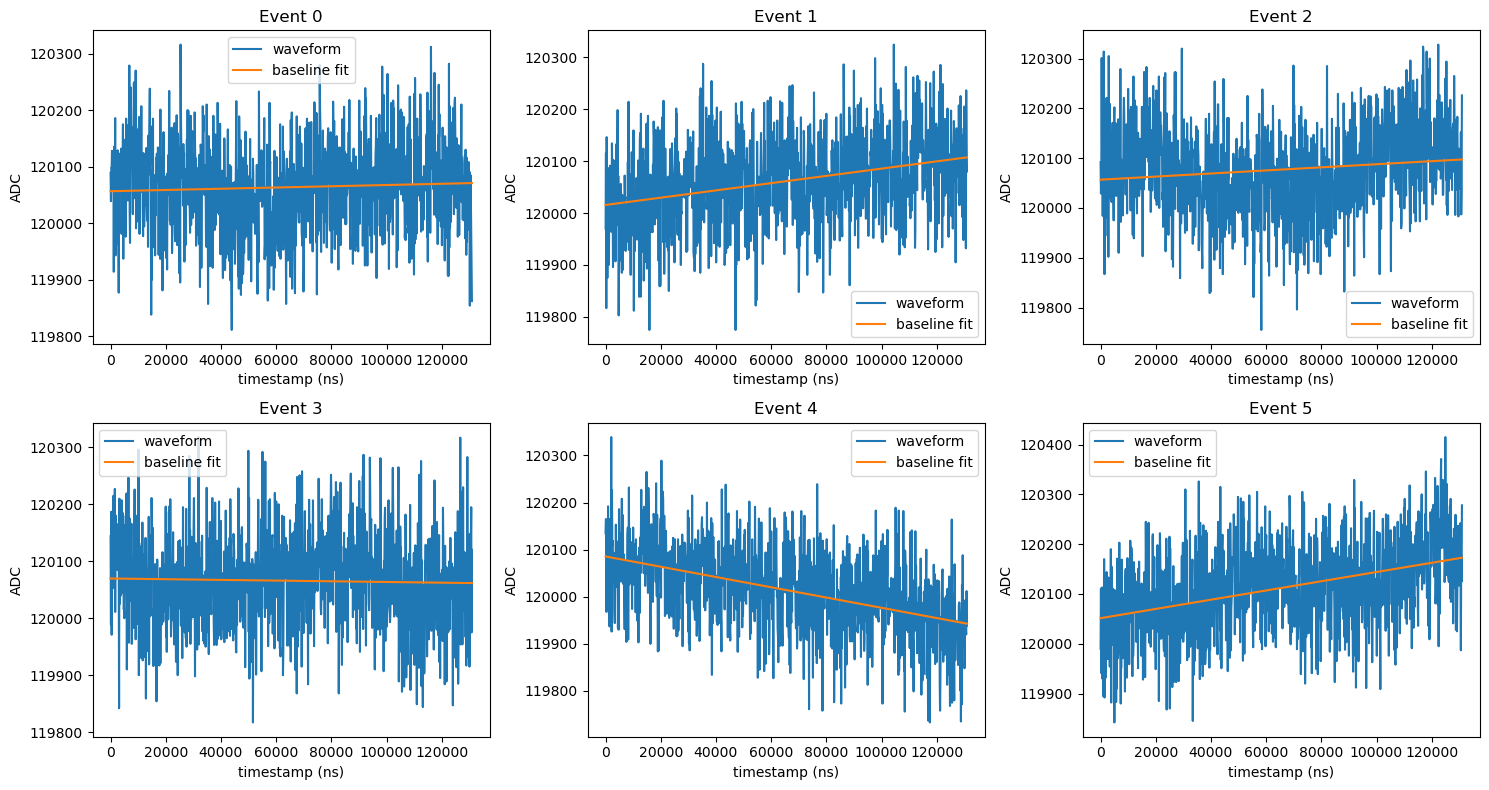

[1.33868723e+02 4.14280636e-06 1.00000626e+00]
[1.53903639 0.01327653 0.01327539]


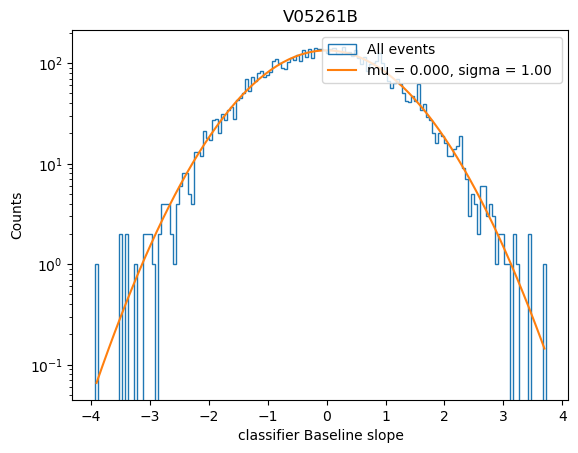

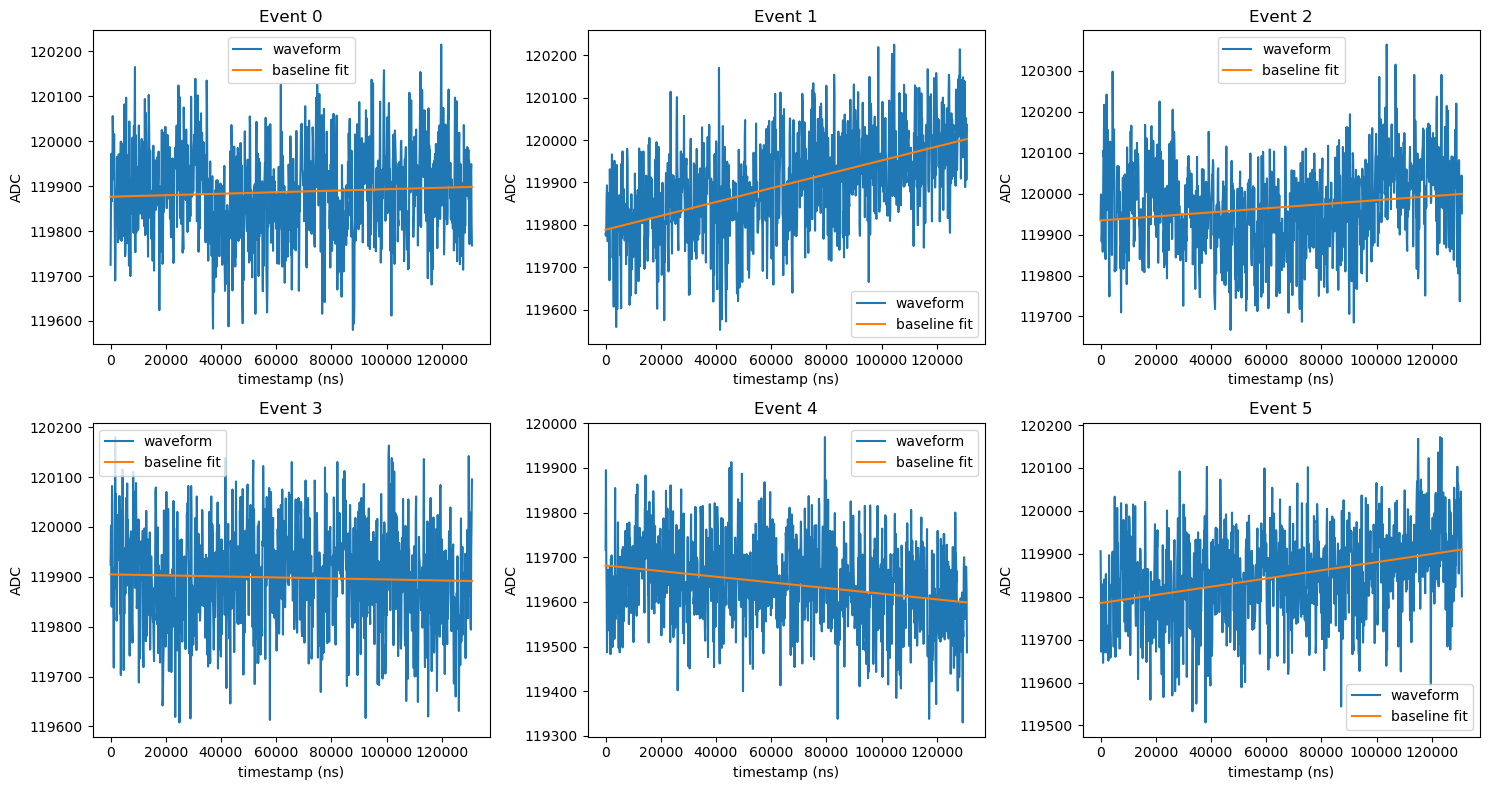

[ 4.74410924e+02 -5.03061974e-07  1.00000234e+00]
[2.65227951 0.00645021 0.00645557]


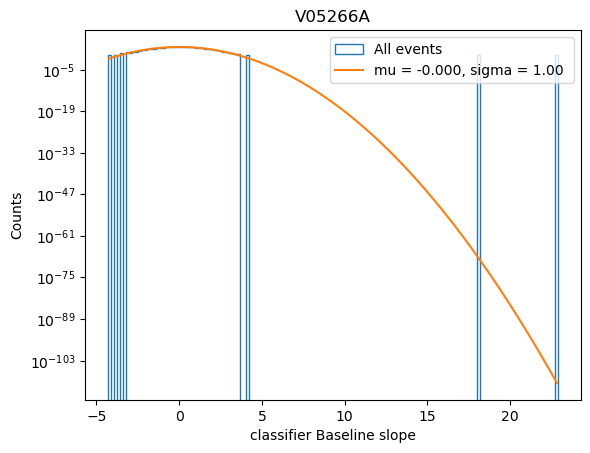

In [42]:

for name , chn in zip(icpc_chmap['name'], chn_icpc[:4]):
    start = time.time()
    data_init = lh5.read_as(f"/ch{int(chn)}/raw", fft_files, field_mask = ["waveform_presummed"], library="ak")
    wfs = data_init["waveform_presummed"]
    wfs_ADC = ak.to_numpy(wfs["values"])
    calcs = fit_baseline_per_event(wfs_ADC)
    n_events = 6

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for i in range(n_events):
    
        wf = wfs_ADC[i]
        t0 = data_init["waveform_presummed"][i]["t0"]
        dt = data_init["waveform_presummed"][i]["dt"]
    
        # asse tempo (o samples se preferisci)
        timestamp = t0 + np.arange(len(wf)) * dt
    
        # baseline fit
        x_fit = np.arange(len(wf))
        baseline = calcs["bl_int"][i] + calcs["bl_slope"][i] * x_fit
    
        ax = axes[i]
        ax.plot(timestamp, wf, label="waveform")
        ax.plot(timestamp, baseline, label="baseline fit")
    
        ax.set_title(f"Event {i}")
        ax.set_xlabel("timestamp (ns)")
        ax.set_ylabel("ADC")
        ax.legend()
    
    plt.tight_layout()
    plt.show()

    counts, bc, _ = plt.hist(calcs["bl_slope"], bins = 150, histtype = 'step')
    be = (bc[1:] + bc[:-1])/2
    
    p0 = [max(counts), 0.1, 0.1]
    popt, pcov = curve_fit(
            gaussian,
            be,
            counts,
            p0=p0,
            maxfev=5000
        )
    mu = popt[1]
    sigma = popt[2]
    plt.close()

    classifier_bl_slope = (calcs["bl_slope"] - mu) / sigma

    counts, bc, _ = plt.hist(classifier_bl_slope, bins = 150, histtype = 'step', label=  "All events")
    
    
    be = (bc[1:] + bc[:-1])/2
    p0 = [max(counts), 0.1, 0.1]
    popt, pcov = curve_fit(
            gaussian,
            be,
            counts,
            p0=p0,
            maxfev=5000
        )
    mu = popt[1]
    sigma = popt[2]
    
    print(popt)
    print(np.sqrt(np.diag(pcov)))
    plt.plot(be, gaussian(be, *popt), label = f"mu = {popt[1]:.3f}, sigma = {popt[2]:.2f} ")
    
    plt.legend(loc = "upper right")
    plt.ylabel(f"Counts")
    plt.xlabel("classifier Baseline slope")
    plt.title(f"{name}")
    plt.yscale('log')

In [43]:
results = []
for name , chn in tqdm(zip(icpc_chmap['name'], chn_icpc)):
    start = time.time()
    data_init = lh5.read_as(f"/ch{int(chn)}/raw", fft_files, field_mask = ["waveform_presummed"], library="ak")
    wfs = data_init["waveform_presummed"]
    wfs_ADC = ak.to_numpy(wfs["values"])
    calcs = fit_baseline_per_event(wfs_ADC)
    results.append(calcs)
    

    counts, bc, _ = plt.hist(calcs["bl_slope"], bins = 150, histtype = 'step')
    be = (bc[1:] + bc[:-1])/2
    
    p0 = [max(counts), 0.1, 0.1]
    popt, pcov = curve_fit(
            gaussian,
            be,
            counts,
            p0=p0,
            maxfev=5000
        )
    mu = popt[1]
    sigma = popt[2]
    plt.close()


41it [00:33,  1.23it/s]


In [44]:

all_data = ak.concatenate(results)

all_slopes = all_data["bl_slope"]

[ 5.83964946e+04 -3.52800308e-04  6.09086341e-02]
[1.88233676e+02 2.26704677e-04 2.26704802e-04]


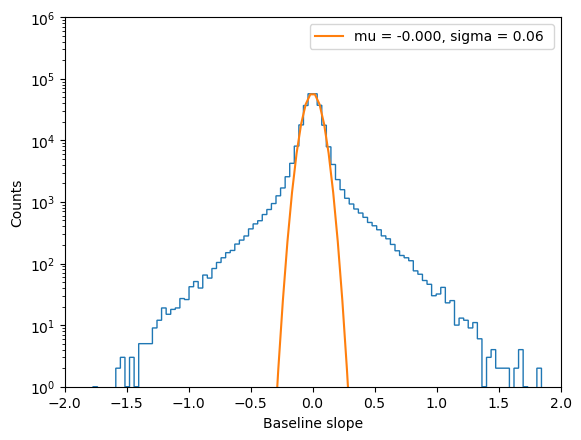

In [45]:

counts, bc, _ = plt.hist(all_slopes, bins = 800, histtype = 'step')
be = (bc[1:] + bc[:-1])/2

p0 = [max(counts), 0.1, 0.1]
popt, pcov = curve_fit(
        gaussian,
        be,
        counts,
        p0=p0,
        maxfev=5000
    )
mu = popt[1]
sigma = popt[2]

print(popt)
print(np.sqrt(np.diag(pcov)))

plt.plot(be, gaussian(be, *popt), label = f"mu = {popt[1]:.3f}, sigma = {popt[2]:.2f} ")

plt.legend(loc = "upper right")
plt.ylim(1,  1e6)
plt.xlim(-2,2)
plt.ylabel(f"Counts")
plt.xlabel("Baseline slope")
plt.yscale('log')